In [5]:
import h5py
import pandas as pd

path = "/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset"
fname = f"{path}/station23_run1000.h5"

with h5py.File(fname, "r") as f:
    waveforms = f["waveforms"][:]        # shape likely (N, 24, 2048)
    run = f["run"][:]
    event_number = f["event_number"][:]
    timestamp = f["timestamp"][:]
    trigger_type = f["trigger_type"][:]

    print("waveforms:", waveforms.shape)
    print("run:", run.shape)
    print("event_number:", event_number.shape)
    print("features keys:", list(f["features"].keys()))

waveforms: (332, 24, 2048)
run: (332,)
event_number: (332,)
features keys: ['coherent_snr_deep', 'max_corr', 'passed_hit_filter', 'snr_avg_deep']


In [7]:
with h5py.File(fname, "r") as f:
    df = pd.DataFrame({
        "run": f["run"][:],
        "event_number": f["event_number"][:],
        "timestamp": f["timestamp"][:],
        "trigger_type": f["trigger_type"][:],
        "waveforms": list(f["waveforms"][:])  # Store waveforms as lists in the DataFrame
    })

    for key in f["features"].keys():
        df[key] = f["features"][key][:]

df.head()

,run,event_number,timestamp,trigger_type,waveforms,coherent_snr_deep,max_corr,passed_hit_filter,snr_avg_deep
0,1000,0,1.663969e+09,1,"[[-0.007033875, 0.0015131333, 0.00822864, 0.01...",1.990087,NaN,0,2.521194
1,1000,1,1.663969e+09,1,"[[-0.0076642535, -0.006443252, -0.0003382459, ...",2.320991,NaN,0,2.553515
2,1000,2,1.663969e+09,1,"[[0.015675599, 0.0071285893, -0.000197418, -0....",78.933296,NaN,1,27.425360
3,1000,3,1.663969e+09,1,"[[0.0103716245, 0.008540123, 0.002435117, -0.0...",2.359924,NaN,0,2.550462
4,1000,4,1.663969e+09,1,"[[-0.0022807608, -0.0041122627, -0.0010597595,...",77.397163,NaN,1,32.925526


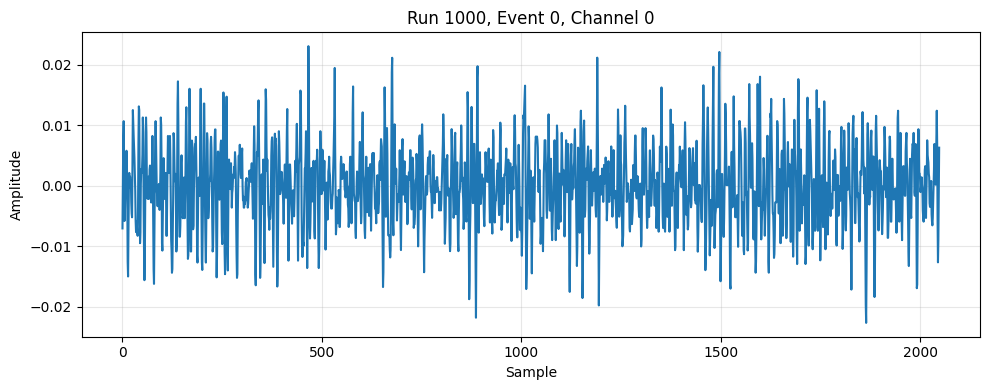

In [8]:
import h5py
import matplotlib.pyplot as plt

path = "/fs/ess/PAS2608/alisa/rno_g/TS_ML/ml_dataset"
fname = f"{path}/station23_run1000.h5"

with h5py.File(fname, "r") as f:

    waveforms = f["waveforms"]

    trace = waveforms[0, 0, :]  # first event, channel 0

    run = f["run"][0]
    event_number = f["event_number"][0]

plt.figure(figsize=(10, 4))
plt.plot(trace)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title(
    f"Run {run}, Event {event_number}, Channel 0"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()